# Customer Segmentation & Behavioral Analysis (EDA)

## Problem Statement

### Context
In an increasingly competitive market, a one-size-fits-all marketing strategy is no longer effective. To maximize Customer Lifetime Value (CLV) and optimize marketing spend, businesses must transition from broad outreach to highly targeted, data-driven customer engagement. The company possesses a rich customer database containing demographic profiles (Age, Gender, Education, Family Size), professional backgrounds (Profession, Work Experience), and historical behavioral data (Spending Scores).

However, this data remains unexploited. Without a clear understanding of who the customers are and how their characteristics influence their purchasing power, the marketing and product teams cannot effectively tailor their offerings.

### Objective
The primary objective of this project is to conduct a rigorous **Exploratory Data Analysis (EDA)** to identify distinct, actionable customer personas and evaluate the structural differences across predefined customer segments (A, B, C, and D).

Specifically, this analysis aims to answer key business questions:
1. **Demographic Distribution:** How do age and family structures vary across different customer segments?
2. **Behavioral Vectors:** What core factors (e.g., age, profession) serve as the strongest indicators of a customer’s spending score ("Low", "Average", "High")?
3. **Feature Engineering & Selection:** Which variables (such as Work Experience) provide a meaningful signal for differentiation, and which ones act as statistical noise and should be excluded from future machine learning pipelines?

### Business Impact
By uncovering these underlying data patterns, this notebook provides the strategic foundation required to split marketing efforts into two distinct tracks: a **volume-driven track** optimized for low-spending entry tiers, and a **value-driven track** engineered to capture premium revenue from high-spending mature cohorts. Furthermore, the insights derived here will serve as the essential feature-selection baseline for building downstream supervised or unsupervised machine learning classification models.

In [ ]:
# Imported the required libraries to support efficient data analysis and visualization.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set visualization style and figure aesthetics.

sns.set_theme(style="whitegrid")
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (7,4)

In [ ]:
# Imported the dataset

df = pd.read_csv("Train.csv")
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


Data Understanding

In [ ]:
# Viewed dataset dimensions.

df.shape

(8068, 11)

In [ ]:
#Review column structure and data types.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [ ]:
# View summary statistics of numerical features.

df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [ ]:
# Identify feature data types.

df.dtypes

,0
ID,int64
Gender,object
Ever_Married,object
Age,int64
Graduated,object
Profession,object
Work_Experience,float64
Spending_Score,object
Family_Size,float64
Var_1,object


In [ ]:
# Count missing values per column.

df.isna().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [ ]:
# Check for duplicate records.

df.duplicated().sum()

np.int64(0)

In [ ]:
#Review column-wise value counts and missing data.

for i in df.columns:
  print(df[i].value_counts())
  print("Missing data :", df[i].isna().sum())
  print("-----------------------")

ID
461879    1
462809    1
462643    1
466315    1
464853    1
         ..
465015    1
464347    1
460156    1
461319    1
462669    1
Name: count, Length: 8068, dtype: int64
Missing data : 0
-----------------------
Gender
Male      4417
Female    3651
Name: count, dtype: int64
Missing data : 0
-----------------------
Ever_Married
Yes    4643
No     3285
Name: count, dtype: int64
Missing data : 140
-----------------------
Age
35    250
37    234
42    232
33    232
27    229
     ... 
78     29
87     28
76     27
80     24
85     22
Name: count, Length: 67, dtype: int64
Missing data : 0
-----------------------
Graduated
Yes    4968
No     3022
Name: count, dtype: int64
Missing data : 78
-----------------------
Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64
Missing data : 124
-----------------------
W

Data Cleaning

In [ ]:
# Analyze impact of age on marital status.

df.groupby('Age')['Ever_Married'].value_counts(normalize=True).unstack().head(20)

Ever_Married,No,Yes
Age,,
18,0.968992,0.031008
19,0.968992,0.031008
20,0.975207,0.024793
21,0.973913,0.026087
22,0.946970,0.053030
23,0.984127,0.015873
25,0.769585,0.230415
26,0.780000,0.220000
27,0.748899,0.251101


In [ ]:
# Missing values in ‘Ever_Married’ were imputed using age-based logic, assuming younger individuals are less likely to be married.
# This approach preserves real-world patterns better than simple imputation.

def fill_married(row):
    if pd.isnull(row['Ever_Married']):
        if row['Age'] < 35:
            return 'No'
        else:
            return 'Yes'
    return row['Ever_Married']

df['Ever_Married'] = df.apply(fill_married, axis=1)
print("Missing data in Ever married column :",df['Ever_Married'].isna().sum())

Missing data in Ever married column : 0


In [ ]:
# Analyze impact of age on graduation status.

df.groupby('Age')['Graduated'].value_counts(normalize=True).unstack().head(20)

Graduated,No,Yes
Age,,
18,0.992308,0.007692
19,0.984962,0.015038
20,0.991870,0.008130
21,0.982609,0.017391
22,1.000000,NaN
23,1.000000,NaN
25,0.511628,0.488372
26,0.505051,0.494949
27,0.431718,0.568282


In [ ]:
# Missing values in the ‘Graduated’ column were imputed using age-based logic,
# assuming individuals above a certain age are more likely to have completed graduation

def fill_graduated(row):
    if pd.isnull(row['Graduated']):
        if row['Age'] < 22:
            return 'No'
        else:
            return 'Yes'
    return row['Graduated']

df['Graduated'] = df.apply(fill_graduated, axis=1)
print("Missing data in graduated column :",df['Graduated'].isna().sum())

Missing data in graduated column : 0


In [ ]:
# Missing values in the ‘Profession’ column were labeled as ‘Unknown’ to avoid introducing bias through incorrect assumptions

df['Profession'].fillna('Unknown', inplace=True)
print("Missing data in Profession column :",df['Profession'].isna().sum())

Missing data in Profession column : 0


In [ ]:
# Since the ‘Var_1’ feature lacks a clear definition and contains minimal missing values,
# missing entries were labeled as ‘Unknown’ to preserve data integrity without introducing bias.

df['Var_1'].fillna('Unknown', inplace=True)
print("Missing data in Var_1 column :",df['Var_1'].isna().sum())

Missing data in Var_1 column : 0


In [ ]:
# Check correlation between age and work experience.

df[['Age', 'Work_Experience']].corr()

,Age,Work_Experience
Age,1.000000,-0.190789
Work_Experience,-0.190789,1.000000


<Axes: xlabel='Age', ylabel='Work_Experience'>

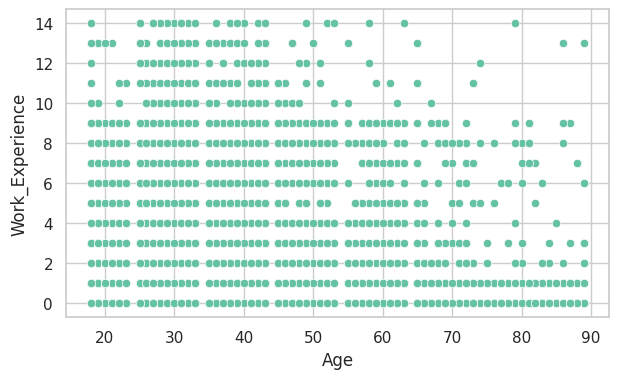

In [ ]:
# Visualize relationship between age and work experience.

sns.scatterplot(x='Age', y='Work_Experience', data=df)

In [ ]:
# From the graph, we observe some unrealistic data points—for example, an 18-year-old with 12 years of work experience.

In [ ]:
# Identify unrealistic cases by assuming minimum working age as 16.

df[df['Work_Experience'] > (df['Age'] - 16)]

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
11,464942,Male,No,19,No,Healthcare,4.0,Low,4.0,Cat_4,D
21,459675,Female,No,18,No,Healthcare,3.0,Low,4.0,Cat_6,D
42,464590,Female,No,27,Yes,Artist,14.0,Low,3.0,Cat_6,A
108,466466,Female,No,19,No,Healthcare,6.0,Low,5.0,Cat_3,D
132,464857,Male,No,18,No,Healthcare,6.0,Low,4.0,Cat_4,D
...,...,...,...,...,...,...,...,...,...,...,...
7811,461280,Male,No,20,No,Healthcare,7.0,Low,4.0,Cat_2,D
7845,467466,Female,No,19,No,Doctor,6.0,Low,2.0,Cat_3,A
7870,462301,Female,No,27,No,Unknown,12.0,Low,3.0,Cat_6,D
7980,459911,Male,No,19,No,Healthcare,4.0,Low,6.0,Cat_2,D


In [ ]:
# Flag entries where experience exceeds valid limit.

df['exp_flag'] = df['Work_Experience'] > (df['Age'] - 16)
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,exp_flag
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D,False
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A,False
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B,False
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B,False
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,Unknown,0.0,Low,7.0,Cat_1,D,False
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D,False
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D,False
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B,False


In [ ]:
# Count flagged vs non-flagged records.

df['exp_flag'].value_counts()

,count
exp_flag,
False,7905
True,163


In [ ]:
# Calculate percentage of flagged records.

df['exp_flag'].mean() * 100

np.float64(2.0203272186415466)

In [ ]:
# Filter out inconsistent age–experience entries. since the percentage of flagged record is below 5 %.

df = df[df['exp_flag'] == False]

In [ ]:
# Check dataset shape after cleaning.

df.shape

(7905, 12)

In [ ]:
# Re-evaluate null values in dataset.

df.isna().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,829
Spending_Score,0
Family_Size,328
Var_1,0


In [ ]:
# Fill null experience values based on profession median.

df['Work_Experience'] = df.groupby('Profession')['Work_Experience'].transform(lambda x: x.fillna(x.median()))

In [ ]:
# Impute missing family size using marital status median.

df['Family_Size'] = df.groupby('Ever_Married')['Family_Size'].transform(lambda x: x.fillna(x.median()))

In [ ]:
# Re-evaluate null values in dataset.

df.isna().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


In [ ]:
# The ‘Age’ variable was transformed into categorical groups (Youth, Young Adults, Middle Age, Elderly, Senior)
# to enable better segmentation analysis and improve interpretability.

bins = [15, 24, 44, 59, 74, 100]
labels = ['Youth', 'Young Adults', 'Middle Age', 'Elderly', 'Senior']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

In [ ]:
# Count records in each age group.

df['Age_Group'].value_counts()

,count
Age_Group,
Young Adults,3897
Middle Age,1928
Elderly,959
Youth,648
Senior,473


In [ ]:
# Recheck column data types.

df.dtypes

,0
ID,int64
Gender,object
Ever_Married,object
Age,int64
Graduated,object
Profession,object
Work_Experience,float64
Spending_Score,object
Family_Size,float64
Var_1,object


In [ ]:
# Check unique values in family size and work experience, as the column is stored as float.

print(df['Family_Size'].unique())
print(df['Work_Experience'].unique())

[4. 3. 1. 2. 6. 5. 8. 7. 9.]
[ 1.  0.  9. 12. 13.  5.  3.  8.  4. 14.  7.  2.  6. 10. 11.]


In [ ]:
# Convert family size and experience to integer type.

df['Family_Size'] = df['Family_Size'].astype(int)
df['Work_Experience'] = df['Work_Experience'].astype(int)

<Axes: xlabel='Work_Experience'>

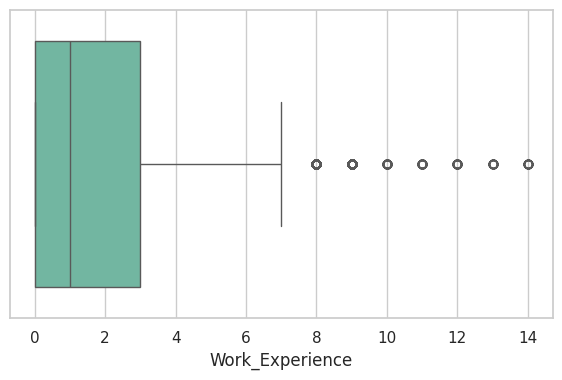

In [ ]:
# Check for outliers in the work experience, age, family size columns.

sns.boxplot(x=df['Work_Experience'])

<Axes: xlabel='Age'>

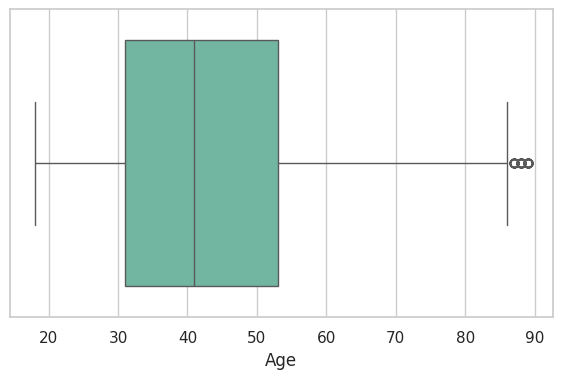

In [ ]:
sns.boxplot(x=df['Age'])

<Axes: xlabel='Family_Size'>

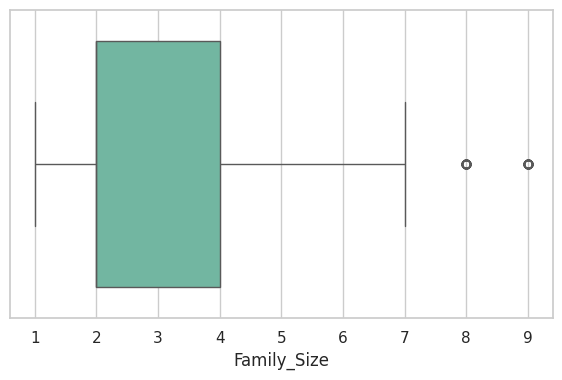

In [ ]:
sns.boxplot(x=df['Family_Size'])

In [ ]:
# Find extreme values of these columns beyond IQR threshold.

In [ ]:
q1 = df['Work_Experience'].quantile(0.25)
q3 = df['Work_Experience'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

df['Work_Experience'][df['Work_Experience']>upper].unique()

array([ 9, 12, 13,  8, 14, 10, 11])

In [ ]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

df['Age'][df['Age']>upper].unique()

array([89, 87, 88])

In [ ]:
q1 = df['Family_Size'].quantile(0.25)
q3 = df['Family_Size'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

df['Family_Size'][df['Family_Size']>upper].unique()

array([8, 9])

In [ ]:
# Outliers identified using the IQR method were evaluated for real-world validity.
# Since most extreme values were realistic, they were retained to preserve natural data distribution.

In [ ]:
# Create experience level categories based on age and work experience.

def exp_level(row):
    if row['Work_Experience'] <= 2:
        if row['Age'] > 30:
            return 'Re-entry / Low Experience'
        else:
            return 'Fresher'
    elif row['Work_Experience'] <= 10:
        return 'Mid'
    else:
        return 'Experienced'

df['Exp_Level'] = df.apply(exp_level, axis=1)

In [ ]:
# Create family size categories based on family size.

def family_category(x):
    if x <= 2:
        return 'Small'
    elif x <= 5:
        return 'Medium'
    else:
        return 'Large'

df['Family_Category'] = df['Family_Size'].apply(family_category)

In [ ]:
# Optimize data types by converting columns to category.

cat_cols = ['Gender','Ever_Married','Spending_Score','Graduated','Profession','Var_1','Segmentation','Age_Group',"Exp_Level","Family_Category"]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [ ]:
# Reorder and select relevant columns for final dataset.

cols = ['ID','Gender','Ever_Married','Age','Age_Group',
        'Graduated','Profession','Work_Experience','Exp_Level',
        'Family_Size','Family_Category',
        'Spending_Score','Var_1','Segmentation']

df = df[cols]

In [ ]:
df

,ID,Gender,Ever_Married,Age,Age_Group,Graduated,Profession,Work_Experience,Exp_Level,Family_Size,Family_Category,Spending_Score,Var_1,Segmentation
0,462809,Male,No,22,Youth,No,Healthcare,1,Fresher,4,Medium,Low,Cat_4,D
1,462643,Female,Yes,38,Young Adults,Yes,Engineer,1,Re-entry / Low Experience,3,Medium,Average,Cat_4,A
2,466315,Female,Yes,67,Elderly,Yes,Engineer,1,Re-entry / Low Experience,1,Small,Low,Cat_6,B
3,461735,Male,Yes,67,Elderly,Yes,Lawyer,0,Re-entry / Low Experience,2,Small,High,Cat_6,B
4,462669,Female,Yes,40,Young Adults,Yes,Entertainment,1,Re-entry / Low Experience,6,Large,High,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,Youth,No,Unknown,0,Fresher,7,Large,Low,Cat_1,D
8064,464685,Male,No,35,Young Adults,No,Executive,3,Mid,4,Medium,Low,Cat_4,D
8065,465406,Female,No,33,Young Adults,Yes,Healthcare,1,Re-entry / Low Experience,1,Small,Low,Cat_6,D
8066,467299,Female,No,27,Young Adults,Yes,Healthcare,1,Fresher,4,Medium,Low,Cat_6,B


Exploratory Data Analysis (EDA)

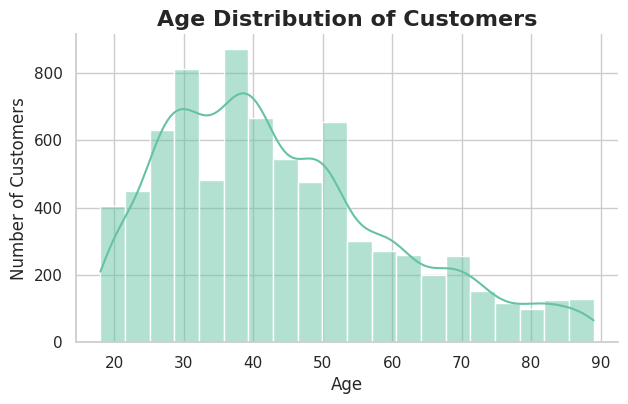

In [ ]:
# Analyze age distribution using histogram and KDE.

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution of Customers', fontsize=16, weight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

sns.despine()

plt.show()

In [ ]:
"""
Peak Target Age: The customer base peaks strongly in the late 30s (specifically around 35–40), with another notable segment around age 30.

Gradual Decline: Beyond age 50, the number of customers steadily declines, showing a much smaller representation of seniors (70+).

Right-Skewed Data: The distribution is skewed to the right, meaning your primary audience heavily leans toward younger and middle-aged adults (25–50).
"""

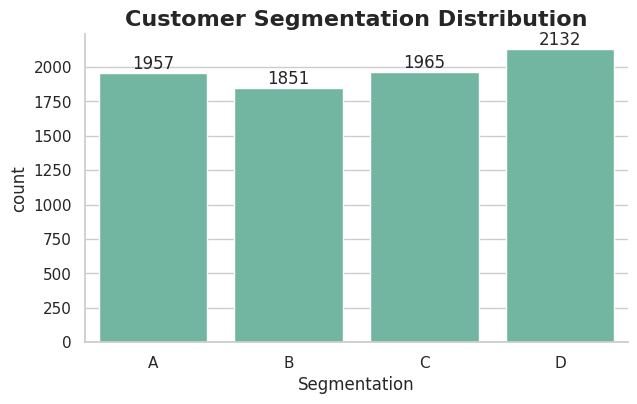

In [ ]:
# Analyze segmentation distribution using count plot.

ax = sns.countplot(data=df, x='Segmentation')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Customer Segmentation Distribution', fontsize=16, weight='bold')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

sns.despine()

plt.show()

In [ ]:
"""
Balanced Segments: The total customer base is relatively evenly split across all four segments (A, B, C, and D).

Top Segment: Segment D is the largest with 2,132 customers.

Smallest Segment: Segment B is the smallest with 1,851 customers, though it isn't lagging significantly behind the others.
"""

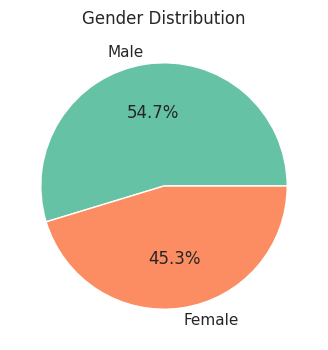

In [ ]:
# Analyze gender-wise distribution with labels.

df['Gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

In [ ]:
"""
Male Dominance: Males make up the majority of the customer base at 54.7%.

Female Representation: Females account for 45.3%, showing a fairly healthy gender balance, though slightly leaning male.
"""

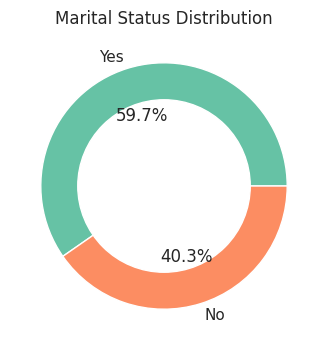

In [ ]:
# Visualize marital status using count plot.

plt.pie(df['Ever_Married'].value_counts(),
        labels=df['Ever_Married'].value_counts().index,
        autopct='%1.1f%%')

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Marital Status Distribution')
plt.show()

In [ ]:
"""
Mostly Married: A clear majority of customers (59.7%) answered "Yes" to being married (or having a partner).

Single/Unmarried: The remaining 40.3% are not married, indicating a significant portion of the audience may have different household purchasing habits.
"""

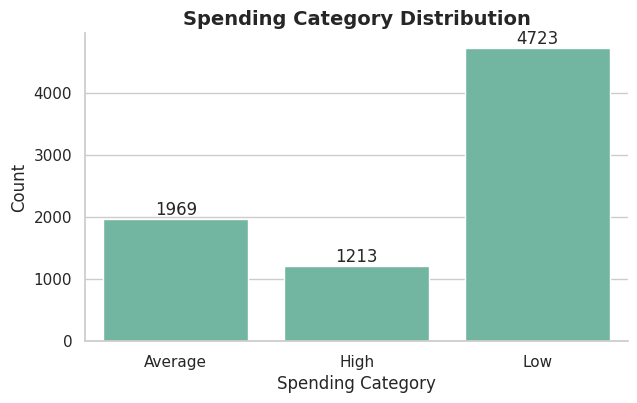

In [ ]:
# Analyze spending categories with labeled counts.

ax = sns.countplot(data=df, x='Spending_Score')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title('Spending Category Distribution', fontsize=14, weight='bold')
plt.xlabel('Spending Category')
plt.ylabel('Count')

sns.despine()
plt.show()

In [ ]:
"""
Dominant Low Spenders: The vast majority of customers fall into the "Low" spending category, with a count of 4,723.

Smallest High Segment: The "High" spending tier is the least populated group, consisting of only 1,213 customers.
"""

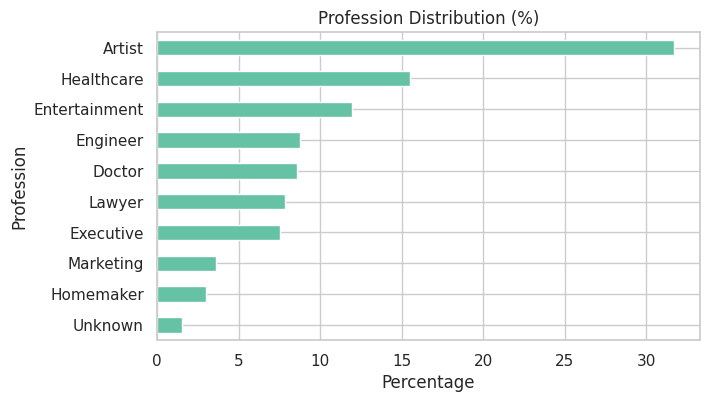

In [ ]:
# Visualize profession-wise distribution.

counts = df['Profession'].value_counts(normalize=True) * 100

counts.sort_values().plot(kind='barh')

plt.title('Profession Distribution (%)')
plt.xlabel('Percentage')
plt.ylabel('Profession')

plt.show()

In [ ]:
"""Top Profession: Artists make up the largest professional segment by a wide margin, accounting for over 30% of the distribution.

Secondary Roles: Healthcare and Entertainment are the next most common professions.

Niche Audiences: Homemakers, Marketing professionals, and those categorized as Unknown represent the smallest fractions of the base.
"""

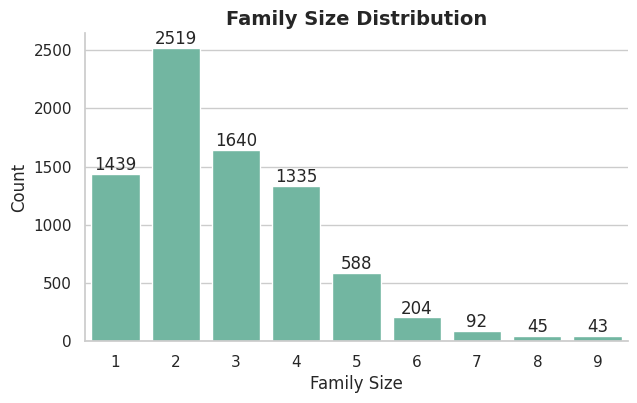

In [ ]:
# Visualize family size distribution using count plot.

ax = sns.countplot(
    data=df,
    x='Family_Size'
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title('Family Size Distribution', fontsize=14, weight='bold')
plt.xlabel('Family Size')
plt.ylabel('Count')

sns.despine()
plt.show()

In [ ]:
"""
Most Common Size: Families consisting of 2 people are highly prevalent, peaking significantly at 2,519.

Downward Trend: There is a sharp, steady decline in customer counts for family sizes of 5 or more, with sizes 7, 8, and 9 being extremely rare.
"""

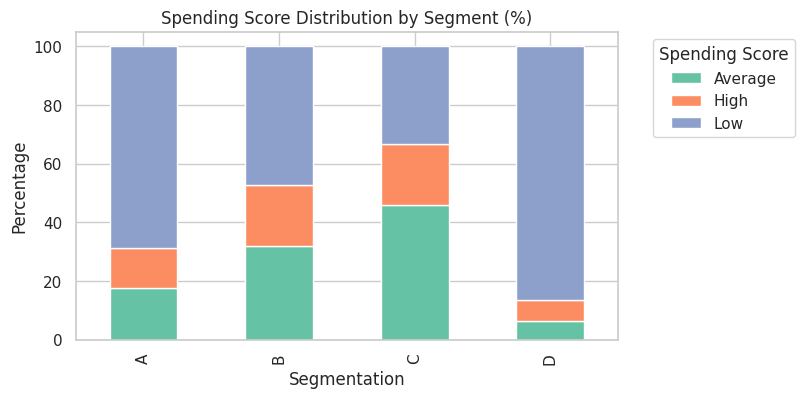

In [ ]:
# Compare spending score distribution across segments.

ct = pd.crosstab(df['Segmentation'], df['Spending_Score'], normalize='index') * 100

ct.plot(kind='bar', stacked=True)

plt.title('Spending Score Distribution by Segment (%)')
plt.ylabel('Percentage')
plt.xlabel('Segmentation')

plt.legend(title='Spending Score', bbox_to_anchor=(1.05, 1))
plt.show()

In [ ]:
"""
Segment D Traits: Segment D stands out dramatically as it is almost entirely comprised of individuals with a "Low" spending score (approaching nearly 90%).

Segment C Value: Segment C holds the highest proportion of "Average" and "High" spending scores compared to all other customer groups.

Segments A and B: Both have a fairly healthy mix, though Segment A leans much more heavily toward "Low" spenders than Segment B.
"""

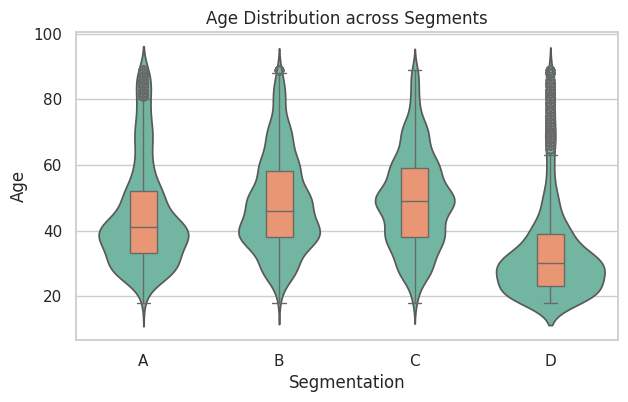

In [ ]:
# Visualize relationship between age groups and segmentation.

sns.violinplot(data=df, x='Segmentation', y='Age', inner=None)
sns.boxplot(data=df, x='Segmentation', y='Age', width=0.2)

plt.title('Age Distribution across Segments')
plt.show()

In [ ]:
"""
Segment D is Significantly Younger: Segment D primarily captures a younger audience, with its median age sitting around 30.

Segments B and C skew Older: Both segments B and C show higher average ages, with their medians trending close to 50.

Segment A is Broad: Segment A covers the widest age spread, maintaining a relatively steady distribution between ages 30 and 55.
"""

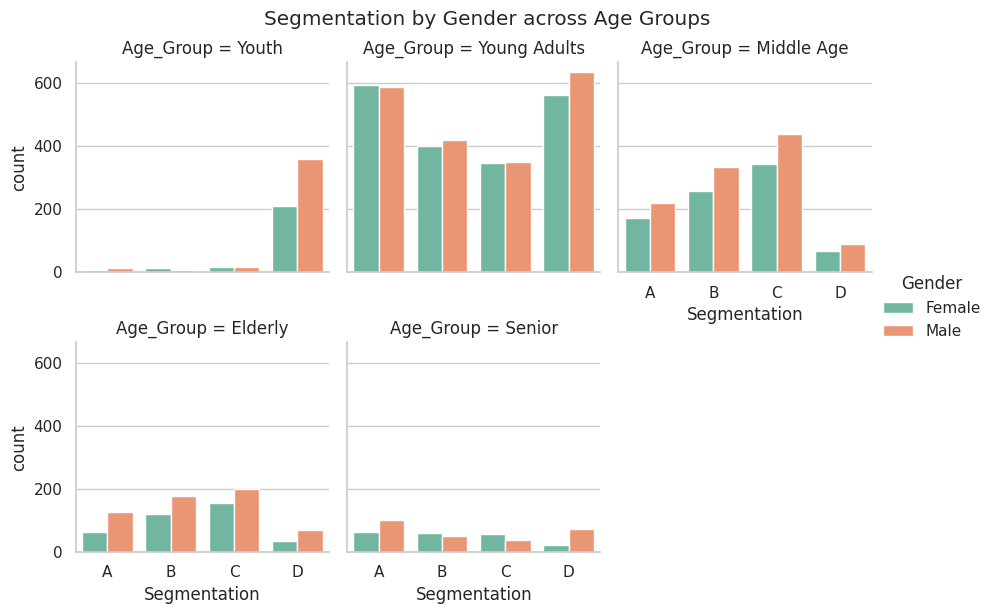

In [ ]:
# Compare customer segments by gender.

g = sns.catplot(data=df, x='Segmentation', hue='Gender', col='Age_Group', kind='count', col_wrap=3,height=3, aspect=1)

g.fig.suptitle('Segmentation by Gender across Age Groups', y=1.02)

plt.show()

In [ ]:
"""
Youth & Young Adults Dominate Segment D: Segment D is overwhelmingly fueled by the "Youth" and "Young Adults" demographics.

Middle Age Favors Segment C: Individuals in the "Middle Age" group lean noticeably toward Segment C.

Minimal Senior Impact: The "Senior" category has very low representation across all customer segments.
"""

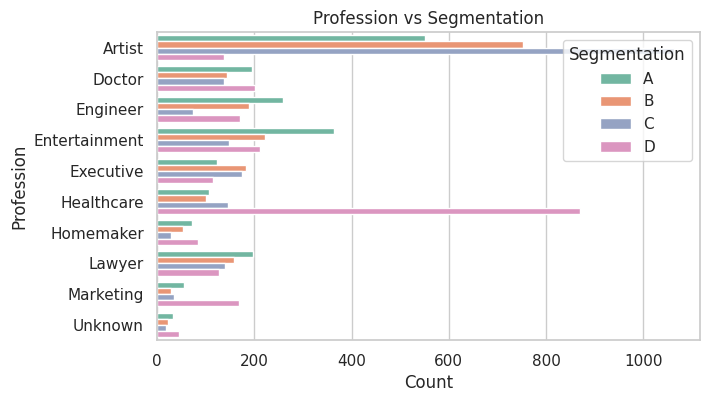

In [ ]:
# Analyze segmentation distribution across professions.

sns.countplot(data=df, y='Profession', hue='Segmentation')

plt.title('Profession vs Segmentation')
plt.xlabel('Count')
plt.ylabel('Profession')

plt.show()

In [ ]:
"""
Healthcare Workers in Segment D: There is a massive concentration of Healthcare professionals strictly within Segment D.

Artists Spread Across A, B, and C: Artists make up a major portion of the customer base but avoid Segment D, grouping heavily into A, B, and C instead.
"""

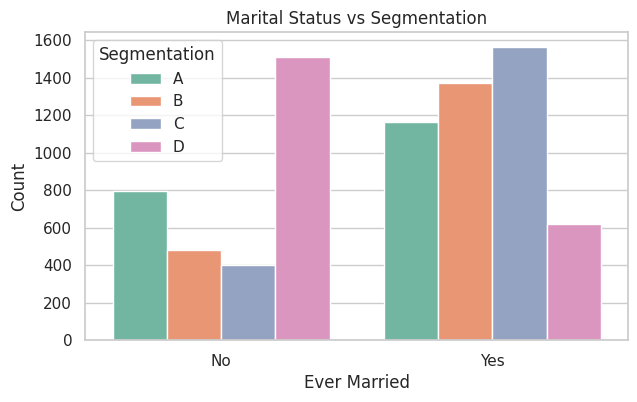

In [ ]:
# Visualize relationship between marital status and segmentation.

sns.countplot(data=df, x='Ever_Married', hue='Segmentation')

plt.title('Marital Status vs Segmentation')
plt.xlabel('Ever Married')
plt.ylabel('Count')

plt.show()

In [ ]:
"""
Unmarried Customers Lean to Segment D: Those who have never been married heavily dominate Segment D.

Married Customers Prefer C and B: Married individuals are much more likely to be classified into Segments C and B.
"""

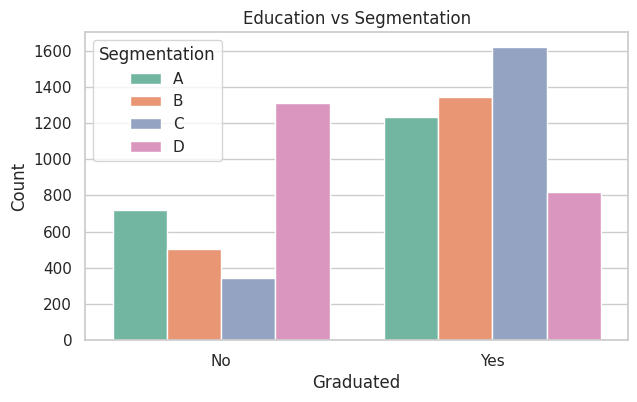

In [ ]:
# Compare customer segments by education level.

sns.countplot(data=df, x='Graduated', hue='Segmentation')

plt.title('Education vs Segmentation')
plt.xlabel('Graduated')
plt.ylabel('Count')

plt.show()

In [ ]:
"""
Graduates Populated in C, B, and A: Customers who have graduated lean strongly toward Segments C, B, and A.

Non-Graduates Concentrated in D: Non-graduates make up the largest piece of Segment D, aligning with the younger age profile of that segment.
"""

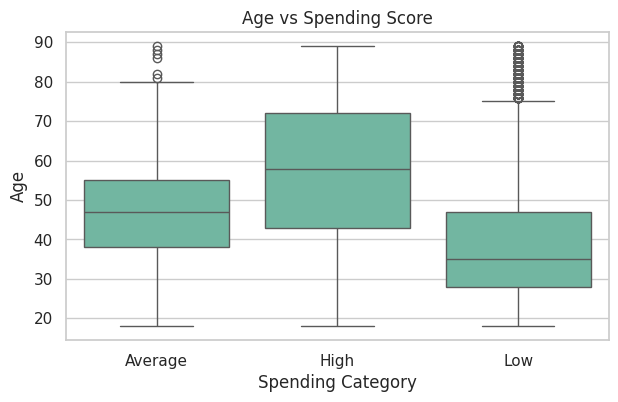

In [ ]:
# Analyze age distribution across spending categories.

sns.boxplot(data=df, x='Spending_Score', y='Age')

plt.title('Age vs Spending Score')
plt.xlabel('Spending Category')
plt.ylabel('Age')

plt.show()

In [ ]:
"""
High Spenders are Older: The median age for "High" spenders sits around 58, notably higher than other categories.

Low Spenders skew Younger: The "Low" spending group represents the youngest segment with a median age of approximately 35.

Average Spenders sit in Middle: The "Average" spending category maintains a steady median age near 47.
"""

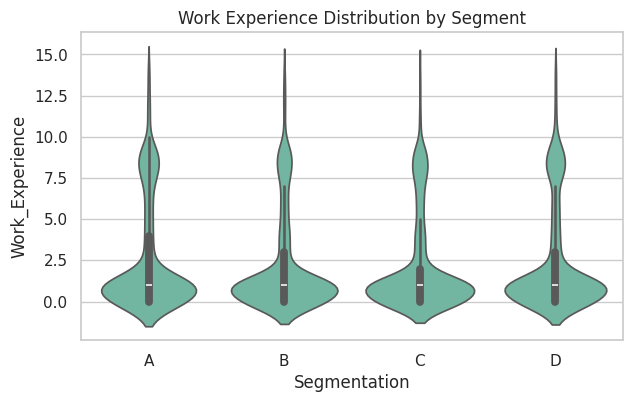

In [ ]:
# Analyze work experience distribution across segments.

sns.violinplot(data=df, x='Segmentation', y='Work_Experience')

plt.title('Work Experience Distribution by Segment')
plt.show()

In [ ]:
"""
Identical Spreads: All four segments (A, B, C, and D) share nearly identical violin plot profiles, with the heaviest density localized at 0–1 year of experience.

Work Experience is a Poor Differentiator: Because the distributions are so uniform, work experience alone will not help separate these customer segments.
"""

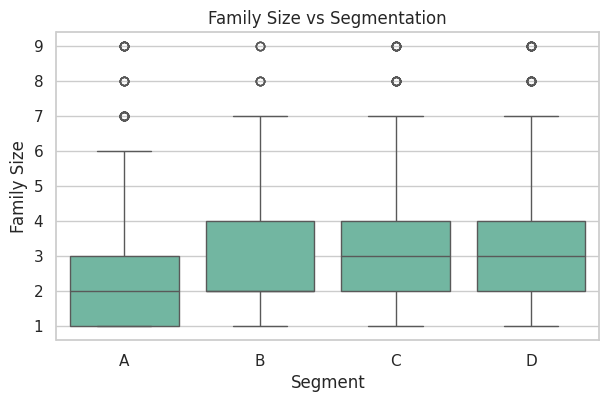

In [ ]:
# Compare family size across customer segments.

sns.boxplot(data=df, x='Segmentation', y='Family_Size')

plt.title('Family Size vs Segmentation')
plt.xlabel('Segment')
plt.ylabel('Family Size')

plt.show()

In [ ]:
"""
Segment A Has Smaller Households: Segment A has a lower median family size of 2 compared to Segments B, C, and D, which all share a median family size of 3.

Similar Extremes: All four groups share identical extreme outliers, reaching up to family sizes of 8 and 9.
"""

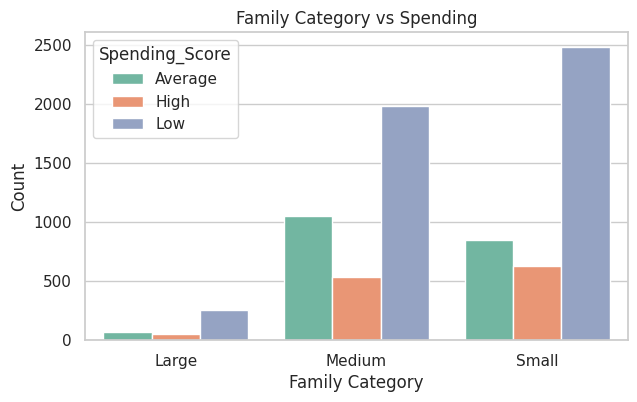

In [ ]:
# Analyze spending patterns across family categories.

sns.countplot(data=df, x='Family_Category', hue='Spending_Score')

plt.title('Family Category vs Spending')
plt.xlabel('Family Category')
plt.ylabel('Count')

plt.show()

In [ ]:
"""
Small Families Drive Low Spending Volume: "Small" families represent the largest block of low spenders, nearing a count of 2,500.

Large Families are Minimal Contributors: "Large" families make up a tiny fraction of the total customer base across all three spending tiers.
"""

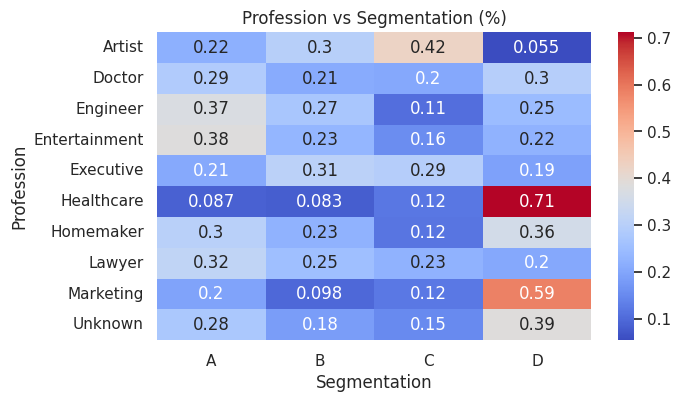

In [ ]:
# Visualize relationship between profession and segmentation using heatmap.

pivot = pd.crosstab(df['Profession'], df['Segmentation'], normalize='index')

sns.heatmap(pivot, annot=True, cmap='coolwarm')

plt.title('Profession vs Segmentation (%)')
plt.show()

In [ ]:
"""
Healthcare Dominates Segment D: 71% of Healthcare professionals map directly into Segment D.
Marketing Prefers Segment D: 59% of Marketing professionals also align heavily with Segment D.
Artists Favor Segment C: Artists show their strongest concentration in Segment C at 42%.
"""

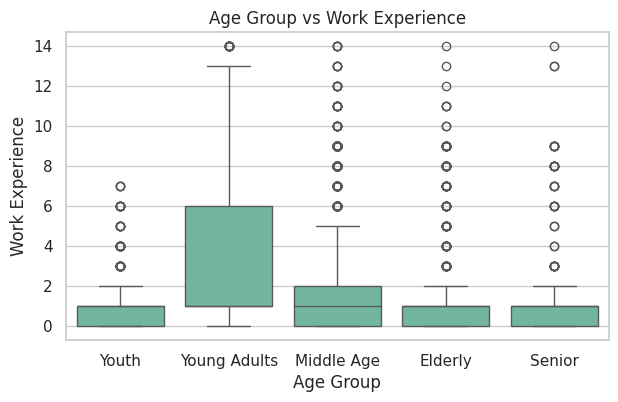

In [ ]:
# Analyze work experience distribution across age groups.

sns.boxplot(data=df, x='Age_Group', y='Work_Experience')

plt.title('Age Group vs Work Experience')
plt.xlabel('Age Group')
plt.ylabel('Work Experience')

plt.show()

In [ ]:
"""
Young Adults Have Most Variance: The "Young Adults" group contains the highest spread of work experience, with a boxplot stretching up to 6 years.

Consistent Floor: All age brackets feature a median or a strong concentration of work experience right around 0–1 year.
"""

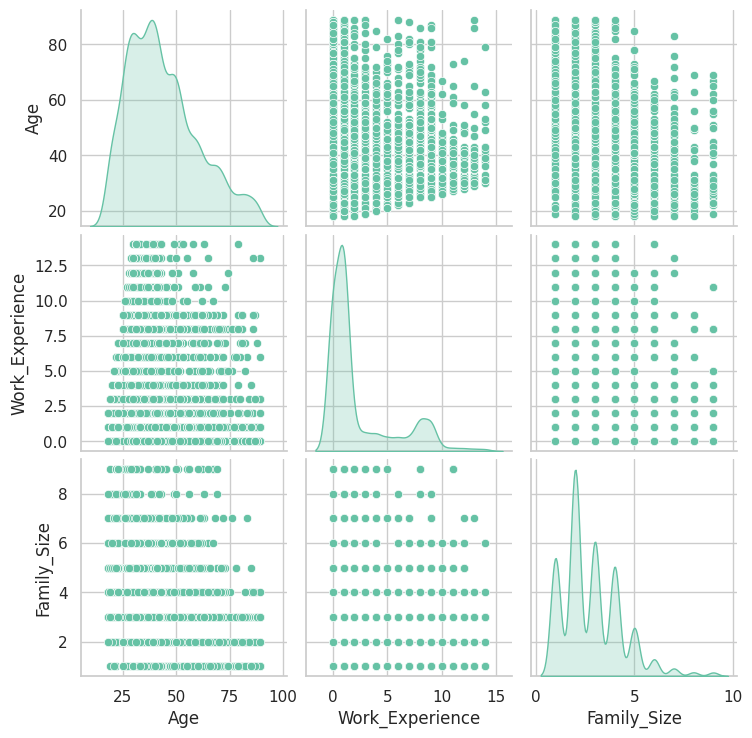

In [ ]:
sns.pairplot(
    df[['Age', 'Work_Experience', 'Family_Size']],
    diag_kind='kde'
)
plt.show()

In [ ]:
"""
Right-Skewed Demographics: The individual distribution curves show that the entire customer data set drops off rapidly as Age, Work Experience, and Family Size increase.

No Linear Correlations: The scatter plots reveal highly grid-like patterns, indicating zero distinct linear relationships between the numeric variables.
"""

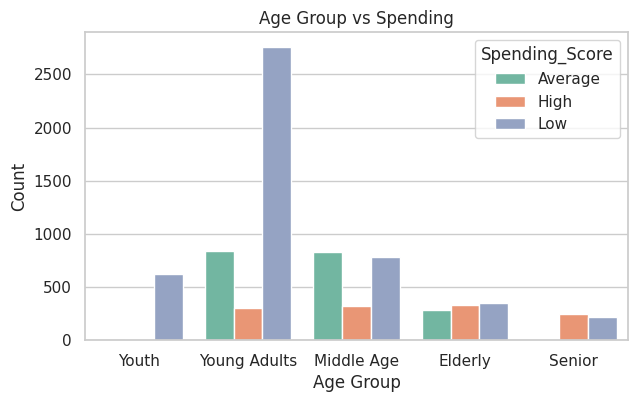

In [ ]:
# Compare spending patterns by age group.

sns.countplot(data=df, x='Age_Group', hue='Spending_Score')

plt.title('Age Group vs Spending')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.show()

In [ ]:
"""
Young Adults Outnumber Low Spenders: The "Young Adults" group produces the single highest volume of "Low" spending scores by a landslide.

Seniors Don't Spend "Low": The "Senior" bracket features virtually zero "Average" spenders and leans heavily toward "High" or "Low" scores relative to its small sample size.
"""

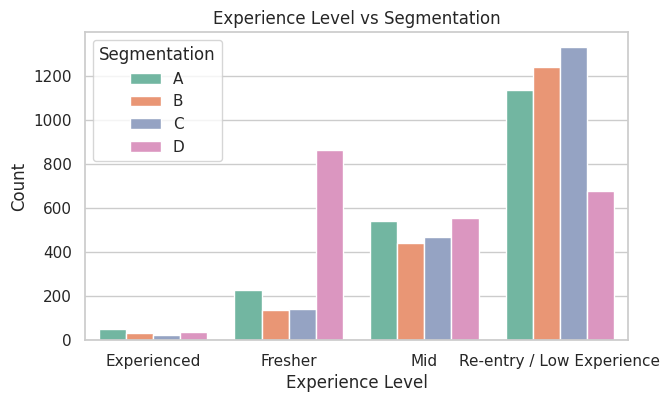

In [ ]:
# Visualize relationship between experience level and segmentation.

sns.countplot(data=df, x='Exp_Level', hue='Segmentation')

plt.title('Experience Level vs Segmentation')
plt.xlabel('Experience Level')
plt.ylabel('Count')

plt.show()

In [ ]:
"""
Freshers Dominate Segment D: Freshers are overwhelmingly concentrated in Segment D, showing a stark contrast to the other segments within that category.

Re-entry / Low Experience Volume: The "Re-entry / Low Experience" group contains the highest overall volume of customers, leaning heavily toward Segments C, B, and A.

Negligible "Experienced" Tier: Customers classified strictly as "Experienced" represent the smallest subset of the data by far.
"""

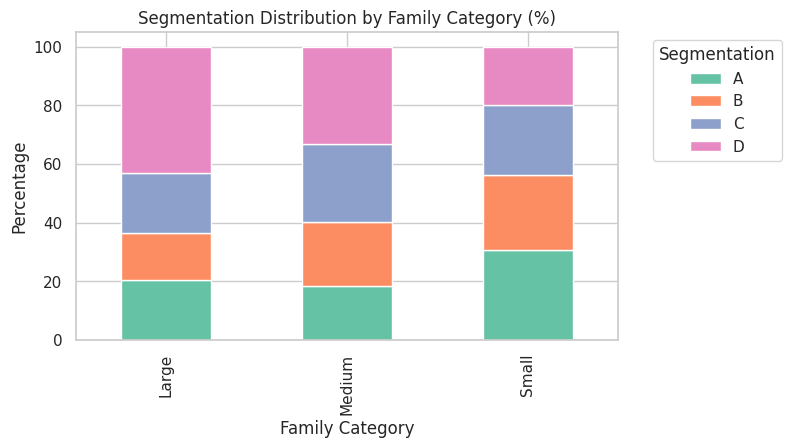

In [ ]:
# Analyze segmentation distribution across family categories.

ct = pd.crosstab(df['Family_Category'], df['Segmentation'], normalize='index') * 100

ct.plot(kind='bar', stacked=True)

plt.title('Segmentation Distribution by Family Category (%)')
plt.xlabel('Family Category')
plt.ylabel('Percentage')
plt.legend(title='Segmentation', bbox_to_anchor=(1.05,1))
plt.show()

In [ ]:
"""
Large Families Bias Toward D: Segment D captures the largest percentage share among "Large" family households, accounting for over 40% of that category.
Small Families Prefer A: "Small" families have a noticeably higher representation in Segment A compared to "Medium" or "Large" families.
Consistent Core: Segments B and C hold relatively steady proportions across both the "Large" and "Medium" family categories.
"""

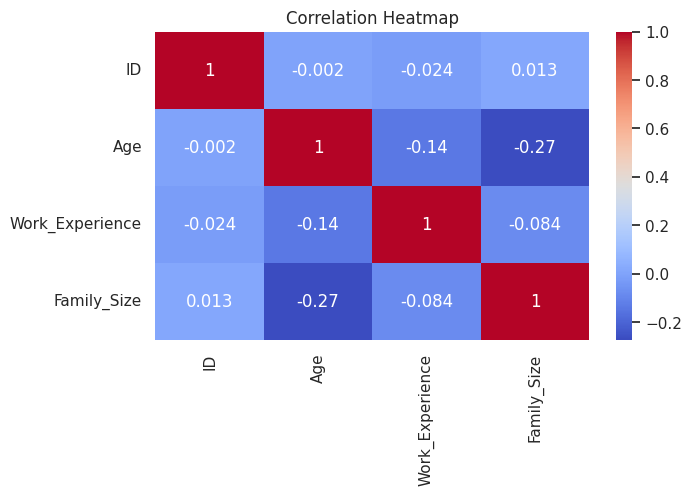

In [ ]:
# Visualize correlations among numeric features using heatmap.

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [ ]:
"""
Weak Negative Correlations: There is a slight negative relationship between Age and Family Size (-0.27), as well as between Age and Work Experience (-0.14).

No Real Linearity: All numerical variables display very weak correlation values close to zero, proving that changes in one metric (like ID or Work Experience) cannot linearly predict another.
"""

# Project Conclusion & Strategic Insights

This Exploratory Data Analysis (EDA) successfully uncovers the underlying structural patterns and customer personas within our database.
While the four primary customer segments (A, B, C, and D) are almost perfectly balanced in total volume, they are heavily polarized by
age, spending behavior, family dynamics, and professional backgrounds.



# Core Customer Segment Profiles


Segment D (The Young, Low-Spending Entry Tier): This is the youngest cohort (median age ~30), predominantly unmarried, non-graduates,
and characterized as "Freshers." Nearly 90% of this segment has a **"Low" spending score, and it is heavily anchored by Healthcare and Marketing professionals.

Segment C (The Mature, High-Value Target Tier): Sitting at an older median age (~50), this segment consists mostly of married couples
and educated graduates. It is the most lucrative tier, boasting the highest proportion of "Average" and "High" spending scores.
Artists represent a major pillar of this segment.

Segment B (The Middle-Aged, Multi-Person Household Tier): Mirroring Segment C's age profile,
Segment B consists of established, married individuals within "Medium" or "Large" families (median size of 3).
They display a stable, balanced mix of low-to-average spending habits.

Segment A (The Ageless, Small-Household Tier): This segment serves as a unique middle ground with the broadest,
most uniform age distribution (ages 30–55). Its defining feature is having the smallest household sizes (median family size of 2).






# Key Macro Takeaways

1. The Spending-Age Correlation: A direct trend indicates that older customers drive premium revenue.
"High" spenders have a median age of 58, whereas "Low" spenders skew much younger with a median age of 35.

2. Household Dynamics: Small, 2-person households are the absolute backbone of overall customer volume,
yet they also make up the largest block of low spenders. Large families (4+ people) shift heavily into Segment D.

3. Variables to Discount: Work Experience proved to be an entirely ineffective variable for segmentation.
All customer profiles shared an identical concentration of 0–1 years of experience, and statistical metrics confirmed
zero linear correlation between experience, age, or family size.




# Data-Driven Recommendations

Volume-Driven Track (Segment D): Deploy low-cost, digital-first acquisition campaigns tailored to young healthcare/entry-level demographics focusing on entry-tier products.

Value-Driven Track (Segment C): Execute relationship-driven, premium product offerings tailored to affluent, mature families with higher disposable incomes.
